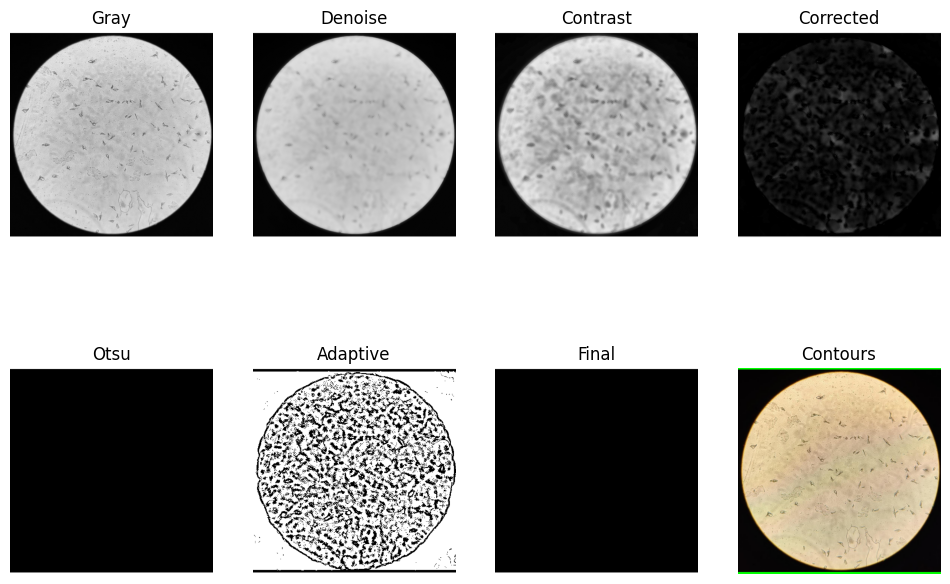

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calcular_areas(imagem_path, area_min=20, area_max=5000):
    img = cv2.imread(imagem_path)
    original = img.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Correção de iluminação irregular
    background = cv2.GaussianBlur(gray, (71, 71), 0)
    corrected = cv2.subtract(gray, background)
    corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)

    # Contraste local
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    contrast = clahe.apply(corrected)

    # Redução de ruído preservando bordas
    denoise = cv2.bilateralFilter(contrast, 9, 75, 75)

    # Segmentação
    thresh = cv2.adaptiveThreshold(
        denoise,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,
        -2
    )

    # Limpeza
    kernel = np.ones((3, 3), np.uint8)
    clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # Contornos
    contours, _ = cv2.findContours(
        clean,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    dados = []
    contador = 1

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area_min <= area <= area_max:
            x, y, w, h = cv2.boundingRect(cnt)
            perimetro = cv2.arcLength(cnt, True)

            dados.append({
                "objeto": contador,
                "area_pixels": area,
                "perimetro_pixels": perimetro,
                "x": x,
                "y": y,
                "largura": w,
                "altura": h
            })

            cv2.drawContours(original, [cnt], -1, (0, 255, 0), 1)
            cv2.putText(
                original,
                str(contador),
                (x, y - 3),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (255, 0, 0),
                1
            )

            contador += 1

    tabela = pd.DataFrame(dados)

    print("Objetos detectados:", len(tabela))
    print("Área total em pixels:", tabela["area_pixels"].sum() if len(tabela) else 0)

    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Objetos detectados com área calculada")
    plt.show()

    return tabela, original, clean


tabela, imagem_resultado, mascara = calcular_areas("ImagemTeste2.png")

print(tabela)